In [5]:
# Importing packages
import numpy as np
import matplotlib.pyplot as plt 
import os

# Setting up a plotting directory in the repository
plot_dir = os.path.join("..", "plots", "eda")
os.makedirs(plot_dir, exist_ok=True)

In [6]:
""" Global parameters """

# Answer to the universe 
np.random.seed(42)

# Number of time periods
T = 1000

In [7]:
""" Implementing Hidden Markov Model """

# Number of hidden states k
k = 2

# Parameters mu (mean) and sigma (variance)
mu = np.array([-3.0, 4.0])
sigma = np.array([1.0, 1.5])

# Transition matrix P 
P = np.array([
    [0.95, 0.05],
    [0.05, 0.95]
])

# Initiating states and series value 
states = np.zeros(T, dtype=int)
y = np.zeros(T)

# Setting first state and series value
states[0] = np.random.choice(k)
y[0] = np.random.normal(loc=mu[states[0]], scale=sigma[states[0]])

# Looping through the time steps t in T
for t in range(1, T):

    # Setting states at time t which is a random choice
    # and saving to variable s
    states[t] = np.random.choice(k, p=P[states[t-1]])
    s = states[t]

    # Time series value at time t is a random normal variable
    # given mean mu and variance sigma for state s
    y[t] = np.random.normal(loc=mu[s], scale=sigma[s])

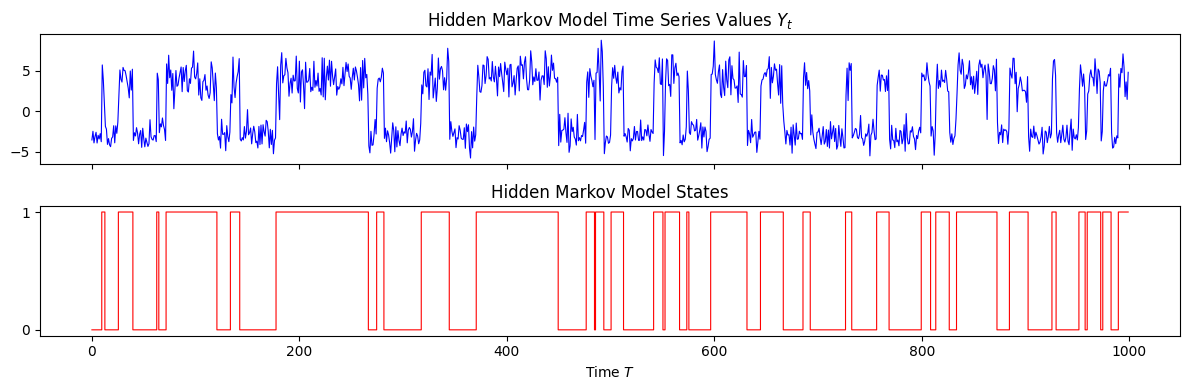

In [8]:
""" Plotting figure """

# Figure size 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 4), sharex=True)

# First panel
ax1.plot(y, color='blue', linewidth=0.8)
ax1.set_title("Hidden Markov Model Time Series Values $Y_t$")

# Second panel
ax2.plot(states, color='red', drawstyle='steps-mid', linewidth=0.8)
ax2.set_title("Hidden Markov Model States")
ax2.set_yticks([0, 1])

# Arguments for both panels
plt.xlabel("Time $T$")

# Tight layout
plt.tight_layout()

# Saving and showing the figure
plt.savefig(os.path.join(plot_dir, "hmm.pdf"), bbox_inches="tight")
plt.show()